# Лабораторная работа №5
## Исследование когнитивных характеристик мозга по данным ЭЭГ

Цель работы — классифицировать когнитивную характеристику мозга по данным ЭЭГ: определение представления движения левого или правого кулака.

В работе используются CSV-файлы:
- MI-EEG-B9T.csv — тренировочная выборка;
- MI-EEG-B9E.csv — тестовая выборка;
- class_MI_EEG_train_9.csv — метки тренировочной выборки;
- class_MI_EEG_test_9.csv — метки тестовой выборки.

Каждый одномерный сигнал ЭЭГ преобразуется в частотно-временное изображение с помощью непрерывного вейвлет-преобразования CWT. Затем полученные скалограммы используются для обучения сверточной нейронной сети.

In [1]:
# =========================
# Cell 2 — Imports
# =========================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pywt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

2026-05-20 04:08:19.147276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779250099.319346      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779250099.377372      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779250099.782884      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779250099.782920      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779250099.782923      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [2]:
# =========================
# Cell 3 — Find dataset files
# =========================

INPUT_ROOT = Path("/kaggle/input")

all_files = [p for p in INPUT_ROOT.rglob("*") if p.is_file()]

print("Files found:")
for p in all_files:
    print(p)

Files found:
/kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/class_MI_EEG_test_9.csv
/kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/class_MI_EEG_train_9.csv
/kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/MI-EEG-B9E.csv
/kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/MI-EEG-B9T.csv


In [3]:
# =========================
# Cell 4 — Define file paths
# =========================

def find_file(filename):
    matches = list(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"File not found: {filename}")
    return matches[0]

train_signal_path = find_file("MI-EEG-B9T.csv")
test_signal_path = find_file("MI-EEG-B9E.csv")

train_target_path = find_file("class_MI_EEG_train_9.csv")
test_target_path = find_file("class_MI_EEG_test_9.csv")

print("Train signals:", train_signal_path)
print("Test signals:", test_signal_path)
print("Train target:", train_target_path)
print("Test target:", test_target_path)

Train signals: /kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/MI-EEG-B9T.csv
Test signals: /kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/MI-EEG-B9E.csv
Train target: /kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/class_MI_EEG_train_9.csv
Test target: /kaggle/input/datasets/abokarim/eeg-motor-imagery-ali-05/class_MI_EEG_test_9.csv


In [4]:
# =========================
# Cell 5 — Load CSV data
# =========================

X_train_raw = pd.read_csv(train_signal_path, header=None).values.astype(np.float32)
X_test_raw = pd.read_csv(test_signal_path, header=None).values.astype(np.float32)

y_train = pd.read_csv(train_target_path, header=None).values.squeeze().astype(np.int32)
y_test = pd.read_csv(test_target_path, header=None).values.squeeze().astype(np.int32)

print("Shapes:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTrain labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())

Shapes:
X_train_raw: (400, 3000)
X_test_raw: (320, 3000)
y_train: (400,)
y_test: (320,)

Train labels:
0    200
1    200
Name: count, dtype: int64

Test labels:
0    160
1    160
Name: count, dtype: int64


In [5]:
# =========================
# Cell 6 — Standardize each EEG signal
# =========================

def standardize_each_signal(X):
    """
    Standardize each row independently:
    x = (x - mean) / std
    """
    X_scaled = np.zeros_like(X, dtype=np.float32)
    
    for i in range(X.shape[0]):
        scaler = StandardScaler()
        X_scaled[i] = scaler.fit_transform(X[i].reshape(-1, 1)).ravel()
    
    return X_scaled

X_train_scaled = standardize_each_signal(X_train_raw)
X_test_scaled = standardize_each_signal(X_test_raw)

print("After standardization:")
print("Train mean example:", X_train_scaled[0].mean())
print("Train std example:", X_train_scaled[0].std())

After standardization:
Train mean example: -1.4305115e-09
Train std example: 1.0


In [6]:
# =========================
# Cell 7 — CWT scalogram function
# =========================

SCALES = np.arange(1, 33)   # 1..32
WAVELET = "cmor1.0-0.5"     # بديل صحيح لـ cmor بدون warning

def signal_to_scalogram(signal_1d):
    """
    Convert 1D EEG signal into normalized CWT scalogram.
    Output shape: (32, 3000)
    """
    coeffs, freqs = pywt.cwt(signal_1d, SCALES, WAVELET)
    
    img = np.abs(coeffs).astype(np.float32)
    
    # Normalization to [0, 1]
    img_min = img.min()
    img_max = img.max()
    img = (img - img_min) / (img_max - img_min + 1e-8)
    
    return img

In [7]:
# =========================
# Cell 8 — Generate CWT scalograms
# =========================

def build_scalogram_dataset(X, name="dataset"):
    images = []
    
    for i in range(X.shape[0]):
        img = signal_to_scalogram(X[i])
        images.append(img)
        
        if (i + 1) % 50 == 0:
            print(f"{name}: processed {i + 1}/{X.shape[0]}")
    
    images = np.array(images, dtype=np.float32)
    
    # Add channel dimension: (N, 32, 3000, 1)
    images = images[..., np.newaxis]
    
    return images

X_train_img = build_scalogram_dataset(X_train_scaled, name="train")
X_test_img = build_scalogram_dataset(X_test_scaled, name="test")

print("X_train_img shape:", X_train_img.shape)
print("X_test_img shape:", X_test_img.shape)

train: processed 50/400
train: processed 100/400
train: processed 150/400
train: processed 200/400
train: processed 250/400
train: processed 300/400
train: processed 350/400
train: processed 400/400
test: processed 50/320
test: processed 100/320
test: processed 150/320
test: processed 200/320
test: processed 250/320
test: processed 300/320
X_train_img shape: (400, 32, 3000, 1)
X_test_img shape: (320, 32, 3000, 1)


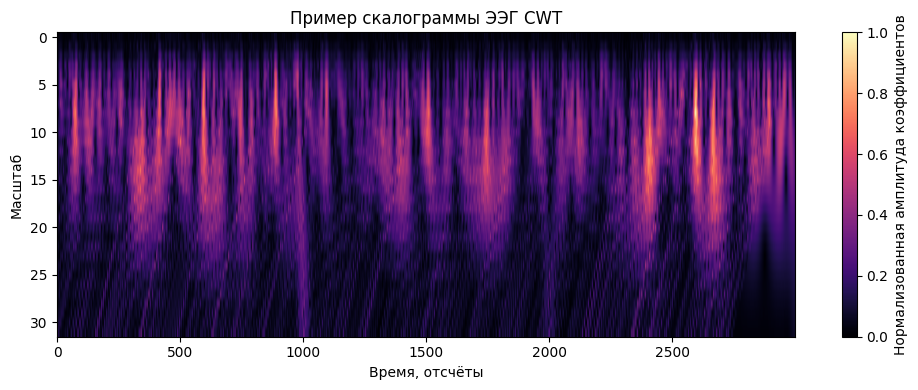

In [8]:
# =========================
# Cell 9 — Display sample scalogram
# =========================

sample_index = 0

plt.figure(figsize=(10, 4))
plt.imshow(X_train_img[sample_index, :, :, 0], aspect="auto", cmap="magma")
plt.title("Пример скалограммы ЭЭГ CWT")
plt.xlabel("Время, отсчёты")
plt.ylabel("Масштаб")
plt.colorbar(label="Нормализованная амплитуда коэффициентов")
plt.tight_layout()

WORK_DIR = Path("/kaggle/working/lab5")
RESULTS_DIR = WORK_DIR / "results"
MODEL_DIR = WORK_DIR / "model"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(RESULTS_DIR / "sample_scalogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# =========================
# Cell 10 — Encode labels and create stratified validation split
# =========================

from sklearn.model_selection import train_test_split

# تحويل labels إلى 0 و 1 مهما كانت قيمها الأصلية
unique_labels = sorted(np.unique(y_train))
print("Original labels:", unique_labels)

label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y_train_enc = np.array([label_to_index[v] for v in y_train], dtype=np.float32)
y_test_enc = np.array([label_to_index[v] for v in y_test], dtype=np.float32)

print("Label mapping:", label_to_index)
print("Encoded train distribution:", np.unique(y_train_enc, return_counts=True))
print("Encoded test distribution:", np.unique(y_test_enc, return_counts=True))

class_names = ["left_fist", "right_fist"]

# تقسيم طبقي صحيح بدل validation_split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_img,
    y_train_enc,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_enc,
    shuffle=True
)

print("Train shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)

print("Train labels:", np.unique(y_train_final, return_counts=True))
print("Validation labels:", np.unique(y_val, return_counts=True))

Original labels: [np.float32(0.0), np.float32(1.0)]
Label mapping: {np.float32(0.0): 0, np.float32(1.0): 1}
Encoded train distribution: (array([0., 1.], dtype=float32), array([200, 200]))
Encoded test distribution: (array([0., 1.], dtype=float32), array([160, 160]))
Train shape: (320, 32, 3000, 1)
Validation shape: (80, 32, 3000, 1)
Train labels: (array([0., 1.], dtype=float32), array([160, 160]))
Validation labels: (array([0., 1.], dtype=float32), array([40, 40]))


In [14]:
# =========================
# Cell 11 — CNN model
# =========================

input_shape = X_train_img.shape[1:]   # (32, 3000, 1)

model = keras.Sequential([
    layers.Input(shape=input_shape),
    
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),
    
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 3000, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 1500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 1500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 1500, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 750, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 750, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    49,152,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,171,073 (187.57 MB)

 Trainable params: 49,171,073 (187.57 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# =========================
# Cell 12 — Train CNN with explicit validation data
# =========================

checkpoint_path = MODEL_DIR / "best_lab5_cnn_cwt.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5588 - loss: 1.5638
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/lab5/model/best_lab5_cnn_cwt.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 541ms/step - accuracy: 0.5571 - loss: 1.5493 - val_accuracy: 0.5000 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5917 - loss: 0.6720
Epoch 2: val_accuracy improved from 0.50000 to 0.60000, saving model to /kaggle/working/lab5/model/best_lab5_cnn_cwt.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 426ms/step - accuracy: 0.5916 - loss: 0.6729 - val_accuracy: 0.6000 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6807 - loss: 0.6847
Epoch 3: val_accuracy did not improve from 0.60000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6799 - loss: 0.6847 - val_accuracy: 0.5625 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━

    accuracy      loss  val_accuracy  val_loss  learning_rate
21  0.978125  0.105795        0.6500  0.889687       0.000125
22  0.965625  0.110923        0.6500  0.902847       0.000125
23  0.987500  0.088055        0.6500  0.941157       0.000125
24  0.971875  0.095930        0.6625  0.922447       0.000125
25  0.987500  0.081509        0.6625  0.941498       0.000063


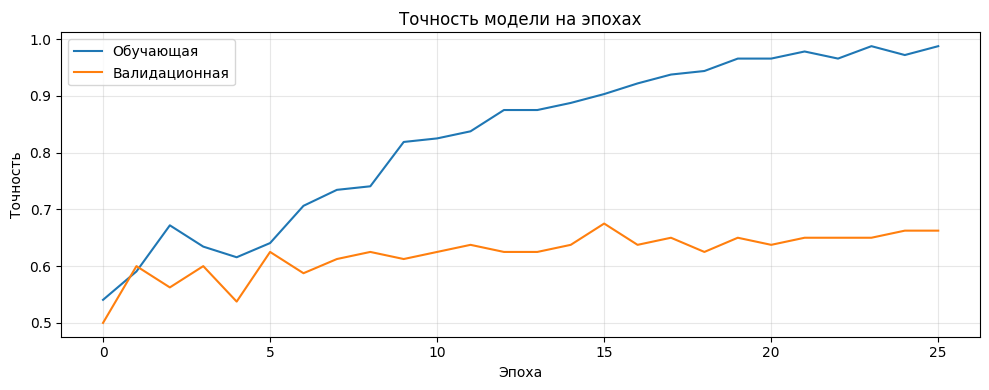

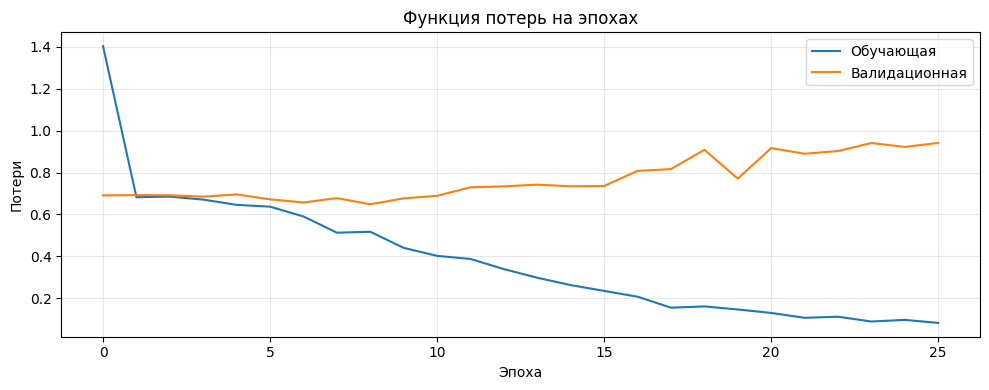

In [16]:
# =========================
# Cell 13 — Training curves
# =========================

history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

print(history_df.tail())

# Accuracy curve
plt.figure(figsize=(10, 4))

plt.plot(history_df["accuracy"], label="Обучающая")
if "val_accuracy" in history_df.columns:
    plt.plot(history_df["val_accuracy"], label="Валидационная")

plt.xlabel("Эпоха")
plt.ylabel("Точность")
plt.title("Точность модели на эпохах")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss curve
plt.figure(figsize=(10, 4))

plt.plot(history_df["loss"], label="Обучающая")
if "val_loss" in history_df.columns:
    plt.plot(history_df["val_loss"], label="Валидационная")

plt.xlabel("Эпоха")
plt.ylabel("Потери")
plt.title("Функция потерь на эпохах")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# =========================
# Cell 14 — Evaluate on test data
# =========================

test_loss, test_accuracy = model.evaluate(
    X_test_img,
    y_test_enc,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7306 - loss: 0.5689
Test loss: 0.6632
Test accuracy: 0.6969


Unique true labels:
(array([0, 1]), array([160, 160]))

Unique predicted labels:
(array([0, 1]), array([231,  89]))

Confusion matrix:
[[147  13]
 [ 84  76]]

Classification report:
              precision    recall  f1-score   support

   left_fist       0.64      0.92      0.75       160
  right_fist       0.85      0.47      0.61       160

    accuracy                           0.70       320
   macro avg       0.75      0.70      0.68       320
weighted avg       0.75      0.70      0.68       320



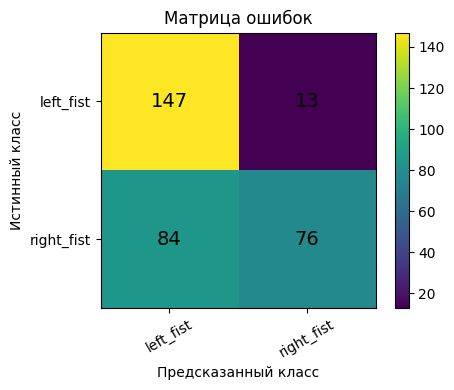

In [18]:
# =========================
# Cell 15 — Classification report and confusion matrix
# =========================

y_pred_prob = model.predict(X_test_img, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(
    y_test_enc.astype(int),
    y_pred,
    labels=[0, 1]
)

report = classification_report(
    y_test_enc.astype(int),
    y_pred,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
)

print("Unique true labels:")
print(np.unique(y_test_enc.astype(int), return_counts=True))

print("\nUnique predicted labels:")
print(np.unique(y_pred, return_counts=True))

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(report)

# Save classification report
with open(RESULTS_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# Save confusion matrix as CSV
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)
cm_df.to_csv(RESULTS_DIR / "confusion_matrix.csv")

# Save prediction probabilities
predictions_df = pd.DataFrame({
    "true_label": y_test_enc.astype(int),
    "predicted_label": y_pred,
    "probability_right_fist": y_pred_prob
})
predictions_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")

plt.xticks(range(len(class_names)), class_names, rotation=30)
plt.yticks(range(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="black"
        )

plt.colorbar()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

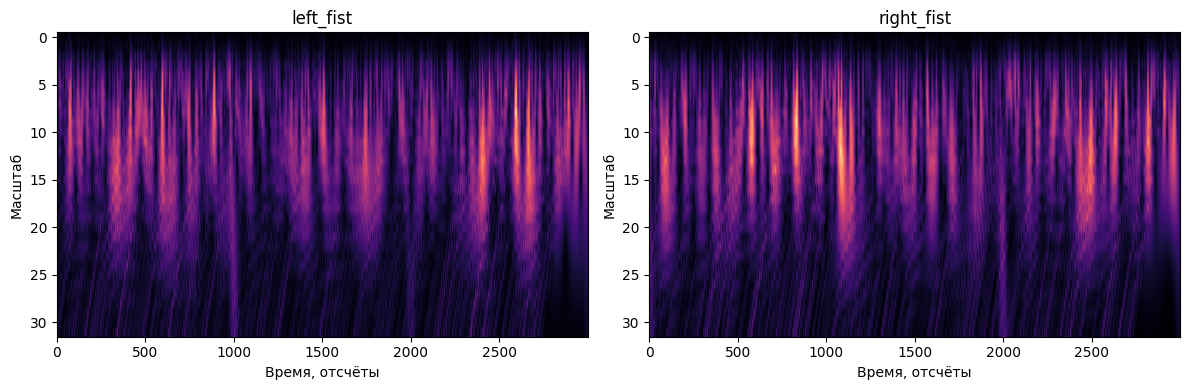

In [19]:
# =========================
# Cell 16 — Save sample scalograms
# =========================

# نأخذ أول مثال من كل فئة من بيانات التدريب
left_indices = np.where(y_train_enc == 0)[0]
right_indices = np.where(y_train_enc == 1)[0]

left_idx = left_indices[0]
right_idx = right_indices[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(X_train_img[left_idx, :, :, 0], aspect="auto", cmap="magma")
axes[0].set_title("left_fist")
axes[0].set_xlabel("Время, отсчёты")
axes[0].set_ylabel("Масштаб")

axes[1].imshow(X_train_img[right_idx, :, :, 0], aspect="auto", cmap="magma")
axes[1].set_title("right_fist")
axes[1].set_xlabel("Время, отсчёты")
axes[1].set_ylabel("Масштаб")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_scalograms.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# =========================
# Cell 17 — Save model and experiment summary
# =========================

final_model_path = MODEL_DIR / "lab5_cnn_cwt_motor_imagery.keras"
model.save(final_model_path)

best_val_accuracy = None
best_val_loss = None

if "val_accuracy" in history_df.columns:
    best_val_accuracy = float(history_df["val_accuracy"].max())

if "val_loss" in history_df.columns:
    best_val_loss = float(history_df["val_loss"].min())

experiment_summary = pd.DataFrame([
    {
        "task": "EEG motor imagery left/right fist classification",
        "dataset_source": "EEG Motor Movement/Imagery Dataset, PhysioNet",
        "train_file": "MI-EEG-B9T.csv",
        "test_file": "MI-EEG-B9E.csv",
        "train_target_file": "class_MI_EEG_train_9.csv",
        "test_target_file": "class_MI_EEG_test_9.csv",
        "train_samples": int(X_train_img.shape[0]),
        "test_samples": int(X_test_img.shape[0]),
        "signal_length": int(X_train_raw.shape[1]),
        "cwt_scales": "1-32",
        "wavelet": WAVELET,
        "train_image_shape": str(X_train_img.shape),
        "test_image_shape": str(X_test_img.shape),
        "best_validation_accuracy": best_val_accuracy,
        "best_validation_loss": best_val_loss,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy),
        "model_path": str(final_model_path),
        "best_model_path": str(checkpoint_path)
    }
])

experiment_summary.to_csv(RESULTS_DIR / "experiment5_summary.csv", index=False)
display(experiment_summary)

print("Final model saved:", final_model_path)
print("Best model saved:", checkpoint_path)

,task,dataset_source,train_file,test_file,train_target_file,test_target_file,train_samples,test_samples,signal_length,cwt_scales,wavelet,train_image_shape,test_image_shape,best_validation_accuracy,best_validation_loss,test_loss,test_accuracy,model_path,best_model_path
0,EEG motor imagery left/right fist classification,"EEG Motor Movement/Imagery Dataset, PhysioNet",MI-EEG-B9T.csv,MI-EEG-B9E.csv,class_MI_EEG_train_9.csv,class_MI_EEG_test_9.csv,400,320,3000,1-32,cmor1.0-0.5,"(400, 32, 3000, 1)","(320, 32, 3000, 1)",0.675,0.648345,0.66316,0.696875,/kaggle/working/lab5/model/lab5_cnn_cwt_motor_...,/kaggle/working/lab5/model/best_lab5_cnn_cwt.k...


Final model saved: /kaggle/working/lab5/model/lab5_cnn_cwt_motor_imagery.keras
Best model saved: /kaggle/working/lab5/model/best_lab5_cnn_cwt.keras


In [21]:
# =========================
# Cell 18 — Create ZIP archive
# =========================

import shutil

archive_path = shutil.make_archive(
    base_name=str(WORK_DIR / "lab5_outputs"),
    format="zip",
    root_dir=WORK_DIR
)

print("Archive created:")
print(archive_path)

print("\nMain outputs:")
print("- results/sample_scalograms.png")
print("- results/cnn_accuracy.png")
print("- results/cnn_loss.png")
print("- results/confusion_matrix.png")
print("- results/classification_report.txt")
print("- results/confusion_matrix.csv")
print("- results/test_predictions.csv")
print("- results/training_history.csv")
print("- results/experiment5_summary.csv")
print("- model/lab5_cnn_cwt_motor_imagery.keras")

Archive created:
/kaggle/working/lab5/lab5_outputs.zip

Main outputs:
- results/sample_scalograms.png
- results/cnn_accuracy.png
- results/cnn_loss.png
- results/confusion_matrix.png
- results/classification_report.txt
- results/confusion_matrix.csv
- results/test_predictions.csv
- results/training_history.csv
- results/experiment5_summary.csv
- model/lab5_cnn_cwt_motor_imagery.keras
